In [56]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout,TooManyRedirects
import json
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = 'https://api.stlouisfed.org/fred/series/observations?series_id=CPIAUCSL&api_key=d7eb18e2083ab93bb96c4ea4977f1647&file_type=json'
parameters = {
    'series_id':'CPIAUCSL',
    'api_key':'d7eb18e2083ab93bb96c4ea4977f1647',
    'file_type':'json'
}
response = requests.get('https://api.stlouisfed.org/fred/series/observations', params=parameters)
data = response.json()
print(data['observations'])

[{'realtime_start': '2026-03-11', 'realtime_end': '2026-03-11', 'date': '1947-01-01', 'value': '21.48'}, {'realtime_start': '2026-03-11', 'realtime_end': '2026-03-11', 'date': '1947-02-01', 'value': '21.62'}, {'realtime_start': '2026-03-11', 'realtime_end': '2026-03-11', 'date': '1947-03-01', 'value': '22.0'}, {'realtime_start': '2026-03-11', 'realtime_end': '2026-03-11', 'date': '1947-04-01', 'value': '22.0'}, {'realtime_start': '2026-03-11', 'realtime_end': '2026-03-11', 'date': '1947-05-01', 'value': '21.95'}, {'realtime_start': '2026-03-11', 'realtime_end': '2026-03-11', 'date': '1947-06-01', 'value': '22.08'}, {'realtime_start': '2026-03-11', 'realtime_end': '2026-03-11', 'date': '1947-07-01', 'value': '22.23'}, {'realtime_start': '2026-03-11', 'realtime_end': '2026-03-11', 'date': '1947-08-01', 'value': '22.4'}, {'realtime_start': '2026-03-11', 'realtime_end': '2026-03-11', 'date': '1947-09-01', 'value': '22.84'}, {'realtime_start': '2026-03-11', 'realtime_end': '2026-03-11', 'da

In [14]:
type(data)

dict

In [30]:
#Looking at Consumer Price Index/Inflation

df = pd.DataFrame(data['observations'])
df = df[['date', 'value']]
df

,date,value
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.0
3,1947-04-01,22.0
4,1947-05-01,21.95
5,1947-06-01,22.08
6,1947-07-01,22.23
7,1947-08-01,22.4
8,1947-09-01,22.84
9,1947-10-01,22.91


In [40]:
df = df[df['value'] != "."]
df['value'] = pd.to_numeric(df['value'])

In [47]:
#looking at quarterly and yearly trends
df2 = df['value'].resample('QE').mean()
df3 = df['value'].resample('YE').mean()
df2, df3

(date
 1947-03-31    21.70000
 1947-06-30    22.01000
 1947-09-30    22.49000
 1947-12-31    23.12667
 1948-03-31    23.61667
 1948-06-30    23.99333
 1948-09-30    24.39667
 1948-12-31    24.17333
 1949-03-31    23.94333
 1949-06-30    23.91667
 1949-09-30    23.71667
 1949-12-31    23.66000
 1950-03-31    23.58667
 1950-06-30    23.76667
 1950-09-30    24.20333
 1950-12-31    24.69333
 1951-03-31    25.69667
 1951-06-30    25.94667
 1951-09-30    25.93333
 1951-12-31    26.31667
 1952-03-31    26.41667
 1952-06-30    26.48667
 1952-09-30    26.66667
 1952-12-31    26.69667
 1953-03-31    26.62000
 1953-06-30    26.72000
 1953-09-30    26.84333
 1953-12-31    26.89000
 1954-03-31    26.95333
 1954-06-30    26.91000
 1954-09-30    26.84000
 1954-12-31    26.75667
 1955-03-31    26.79333
 1955-06-30    26.75667
 1955-09-30    26.77667
 1955-12-31    26.85667
 1956-03-31    26.86000
 1956-06-30    27.03667
 1956-09-30    27.31667
 1956-12-31    27.55000
 1957-03-31    27.77667
 1957-06-3

In [50]:
type(df2)

pandas.core.series.Series

In [52]:
df4 = df2.to_frame(name='values')
df4

,values
date,
1947-03-31,21.70000
1947-06-30,22.01000
1947-09-30,22.49000
1947-12-31,23.12667
1948-03-31,23.61667
1948-06-30,23.99333
1948-09-30,24.39667
1948-12-31,24.17333
1949-03-31,23.94333


In [53]:
df4.count()

values    317
dtype: int64

In [55]:
#changing column name
df5 = df4.rename(columns={'values':'Quarterly_CPI'})
df5

,Quarterly_CPI
date,
1947-03-31,21.70000
1947-06-30,22.01000
1947-09-30,22.49000
1947-12-31,23.12667
1948-03-31,23.61667
1948-06-30,23.99333
1948-09-30,24.39667
1948-12-31,24.17333
1949-03-31,23.94333


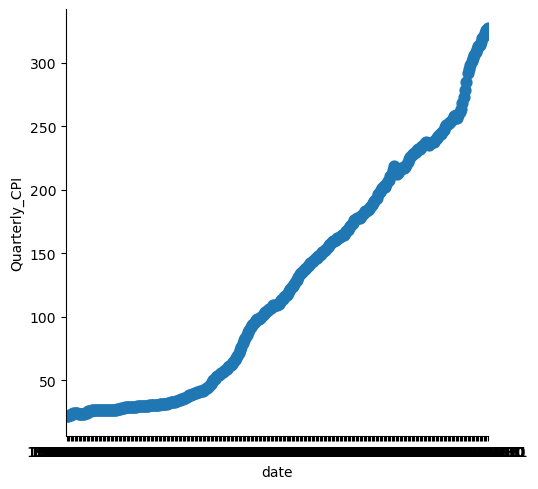

In [58]:
sns.catplot(x='date', y='Quarterly_CPI',data=df5, kind='point')

In [69]:
#Creating final DF

df_final = df3.to_frame(name='Quarterly_CPI').reset_index()
df_final = df_final[['date', 'Quarterly_CPI']]
df_final

,date,Quarterly_CPI
0,1947-12-31,22.33167
1,1948-12-31,24.04500
2,1949-12-31,23.80917
3,1950-12-31,24.06250
4,1951-12-31,25.97333
5,1952-12-31,26.56667
6,1953-12-31,26.76833
7,1954-12-31,26.86500
8,1955-12-31,26.79583
9,1956-12-31,27.19083


<Axes: xlabel='date', ylabel='Quarterly_CPI'>

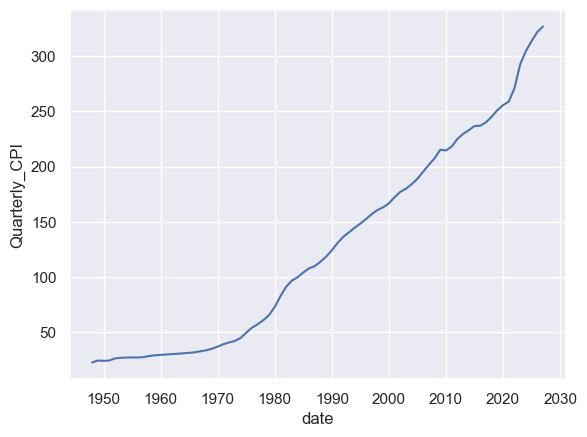

In [70]:
sns.set_theme(style="darkgrid")

sns.lineplot(x='date', y='Quarterly_CPI',data = df_final)